In [1]:
!pip install transformers datasets tokenizers sentencepiece torch scikit-learn -q

In [3]:
import os
import time
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Upload your zip file using Colab files upload, OR mount Drive
# If you have the CSV files directly, just set the paths below

from google.colab import files
import zipfile, io

uploaded = files.upload()  # upload archive.zip here

with zipfile.ZipFile("archive.zip", "r") as z:
    z.extractall("sst2_data")

train_df = pd.read_csv("sst2_data/Finalv SST-2 dataset CSV format/train.csv")
val_df   = pd.read_csv("sst2_data/Finalv SST-2 dataset CSV format/val.csv")
test_df  = pd.read_csv("sst2_data/Finalv SST-2 dataset CSV format/test.csv")

print(train_df.head())
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Columns:", train_df.columns.tolist())

Saving archive.zip to archive.zip
   label                                           sentence
0      1  A stirring, funny and finally transporting re-...
1      0  Apparently reassembled from the cutting-room f...
2      0  They presume their audience won't sit still fo...
3      1  This is a visually stunning rumination on love...
4      1  Jonathan Parker's Bartleby should have been th...
Train: (6920, 2) Val: (872, 2) Test: (1821, 2)
Columns: ['label', 'sentence']


In [5]:
# Standardize column names (adjust if yours differ)
def normalize(df):
    df.columns = [c.strip().lower() for c in df.columns]
    # rename to 'sentence' and 'label' if needed
    if 'sentence' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'sentence'})
    if 'label' not in df.columns:
        df = df.rename(columns={df.columns[1]: 'label'})
    df = df[['sentence', 'label']].dropna()
    df['label'] = df['label'].astype(int)
    return df

train_df = normalize(train_df)
val_df   = normalize(val_df)
test_df  = normalize(test_df)

# Use a small subset for faster Colab runs (remove/increase if you have GPU)
train_df = train_df.sample(3000, random_state=42).reset_index(drop=True)
val_df   = val_df.sample(500, random_state=42).reset_index(drop=True)

print("Label distribution:\n", train_df['label'].value_counts())

Label distribution:
 label
1    1564
0    1436
Name: count, dtype: int64


In [6]:
class SSTDataset(Dataset):
    def __init__(self, df, tokenize_fn, max_len=128):
        self.sentences = df['sentence'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenize_fn = tokenize_fn
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.tokenize_fn(self.sentences[idx], self.max_len), self.labels[idx]


def collate_fn(batch):
    encodings, labels = zip(*batch)
    input_ids      = torch.stack([e['input_ids'] for e in encodings])
    attention_mask = torch.stack([e['attention_mask'] for e in encodings])
    token_type_ids = torch.stack([e.get('token_type_ids',
                       torch.zeros(input_ids.shape[1], dtype=torch.long)) for e in encodings])
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'token_type_ids': token_type_ids
    }, torch.tensor(labels)

In [7]:
class BERTClassifier(torch.nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = torch.nn.Dropout(0.3)
        self.fc   = torch.nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask, token_type_ids):
        out = self.bert(input_ids=input_ids,
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        return self.fc(self.drop(out.pooler_output))

In [8]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion = torch.nn.CrossEntropyLoss()
    for batch, labels in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch, labels in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            logits = model(input_ids, attention_mask, token_type_ids)
            preds  = torch.argmax(logits, dim=1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.numpy())
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='weighted')
    return acc, f1


def run_experiment(tokenize_fn, name, epochs=2, batch_size=16):
    print(f"\n{'='*50}")
    print(f"Running: {name}")
    print(f"{'='*50}")

    train_ds = SSTDataset(train_df, tokenize_fn)
    val_ds   = SSTDataset(val_df, tokenize_fn)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model = BERTClassifier().to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0,
                                                   num_training_steps=total_steps)
    start = time.time()
    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, optimizer, scheduler, device)
        acc, f1 = evaluate(model, val_loader, device)
        print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

    elapsed = time.time() - start
    param_count = sum(p.numel() for p in model.parameters()) / 1e6

    print(f"\nTraining Time : {elapsed:.2f}s")
    print(f"Model Size    : {param_count:.2f}M parameters")
    return {'name': name, 'accuracy': acc, 'f1': f1,
            'training_time_s': elapsed, 'model_size_M': param_count}

In [9]:
wp_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def wordpiece_tokenize(text, max_len=128):
    enc = wp_tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return {k: v.squeeze(0) for k, v in enc.items()}

results_wp = run_experiment(wordpiece_tokenize, "WordPiece (Baseline)")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Running: WordPiece (Baseline)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Loss: 0.3978 | Acc: 0.8920 | F1: 0.8919
Epoch 2 | Loss: 0.1805 | Acc: 0.8880 | F1: 0.8880

Training Time : 136.80s
Model Size    : 109.48M parameters


In [10]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

# Save corpus to file for BPE training
corpus_path = "sst2_corpus.txt"
with open(corpus_path, "w") as f:
    for sent in train_df['sentence'].tolist():
        f.write(sent.strip() + "\n")

bpe_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=30522,
    special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
)
bpe_tokenizer.train([corpus_path], trainer)

# Add post-processor for [CLS] and [SEP]
bpe_tokenizer.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    special_tokens=[("[CLS]", bpe_tokenizer.token_to_id("[CLS]")),
                    ("[SEP]", bpe_tokenizer.token_to_id("[SEP]"))]
)

bpe_tokenizer.enable_padding(pad_id=bpe_tokenizer.token_to_id("[PAD]"),
                              pad_token="[PAD]", length=128)
bpe_tokenizer.enable_truncation(max_length=128)

print("BPE vocab size:", bpe_tokenizer.get_vocab_size())

BPE vocab size: 15129


In [11]:
def bpe_tokenize(text, max_len=128):
    enc = bpe_tokenizer.encode(text)
    input_ids      = torch.tensor(enc.ids[:max_len] + [0]*(max_len - len(enc.ids[:max_len])))
    attention_mask = torch.tensor(enc.attention_mask[:max_len] + [0]*(max_len - len(enc.attention_mask[:max_len])))
    token_type_ids = torch.zeros(max_len, dtype=torch.long)
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'token_type_ids': token_type_ids}

results_bpe = run_experiment(bpe_tokenize, "BPE Tokenization")


Running: BPE Tokenization


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Loss: 0.7076 | Acc: 0.5020 | F1: 0.3369
Epoch 2 | Loss: 0.6977 | Acc: 0.4960 | F1: 0.3289

Training Time : 145.98s
Model Size    : 109.48M parameters


In [12]:
def char_tokenize(text, max_len=128):
    # Map each character to an id (simple vocab: printable ASCII)
    chars = list(text[:max_len - 2])   # leave room for CLS/SEP
    # use BERT vocab ids for printable chars (fallback: hash mod vocab_size)
    vocab_size = 30522
    cls_id, sep_id, pad_id = 101, 102, 0

    ids = [cls_id]
    for c in chars:
        ids.append(hash(c) % (vocab_size - 5) + 5)   # offset to avoid special tokens
    ids.append(sep_id)

    pad_len = max_len - len(ids)
    attention_mask = [1]*len(ids) + [0]*pad_len
    ids            = ids + [pad_id]*pad_len

    return {
        'input_ids':      torch.tensor(ids[:max_len], dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask[:max_len], dtype=torch.long),
        'token_type_ids': torch.zeros(max_len, dtype=torch.long)
    }

results_char = run_experiment(char_tokenize, "Character-level Tokenization")


Running: Character-level Tokenization


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Loss: 0.7048 | Acc: 0.4960 | F1: 0.3324
Epoch 2 | Loss: 0.6871 | Acc: 0.6000 | F1: 0.5878

Training Time : 150.30s
Model Size    : 109.48M parameters


In [13]:
def hybrid_tokenize(text, max_len=128):
    """
    Word-level tokens via BERT WordPiece, but OOV words are
    broken into character-level token IDs.
    """
    vocab_size = 30522
    cls_id, sep_id, pad_id, unk_id = 101, 102, 0, 100

    words = text.split()
    ids = [cls_id]
    for word in words:
        enc = wp_tokenizer.encode(word, add_special_tokens=False)
        if unk_id in enc:
            # Character fallback for OOV
            for c in word:
                ids.append(hash(c) % (vocab_size - 5) + 5)
        else:
            ids.extend(enc)
        if len(ids) >= max_len - 1:
            break
    ids.append(sep_id)

    pad_len = max_len - len(ids)
    attention_mask = [1]*len(ids) + [0]*pad_len
    ids            = ids + [pad_id]*pad_len

    return {
        'input_ids':      torch.tensor(ids[:max_len], dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask[:max_len], dtype=torch.long),
        'token_type_ids': torch.zeros(max_len, dtype=torch.long)
    }

results_hybrid = run_experiment(hybrid_tokenize, "Hybrid Tokenization (Word + Char)")


Running: Hybrid Tokenization (Word + Char)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Loss: 0.3993 | Acc: 0.8820 | F1: 0.8820
Epoch 2 | Loss: 0.1723 | Acc: 0.8900 | F1: 0.8900

Training Time : 148.66s
Model Size    : 109.48M parameters


In [14]:
def dynamic_merge_tokenize(text, max_len=128):
    """
    Tokenize with WordPiece, then merge consecutive ## sub-word tokens
    back into single token IDs (average their embeddings conceptually
    by representing them as the first sub-word ID).
    """
    tokens = wp_tokenizer.tokenize(text)
    merged = []
    for tok in tokens:
        if tok.startswith("##") and merged:
            pass   # drop sub-word; keep only root (dynamic merging)
        else:
            merged.append(tok)

    merged_text = " ".join(merged)
    enc = wp_tokenizer(
        merged_text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return {k: v.squeeze(0) for k, v in enc.items()}

results_dynamic = run_experiment(dynamic_merge_tokenize, "Dynamic Token Merging")


Running: Dynamic Token Merging


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Loss: 0.4416 | Acc: 0.8920 | F1: 0.8919
Epoch 2 | Loss: 0.1977 | Acc: 0.8960 | F1: 0.8960

Training Time : 147.45s
Model Size    : 109.48M parameters


In [15]:
all_results = [results_wp, results_bpe, results_char, results_hybrid, results_dynamic]
results_df  = pd.DataFrame(all_results)
results_df  = results_df.set_index('name')

print("\n" + "="*70)
print("FINAL COMPARISON TABLE")
print("="*70)
print(results_df.to_string())


FINAL COMPARISON TABLE
                                   accuracy        f1  training_time_s  model_size_M
name                                                                                
WordPiece (Baseline)                  0.888  0.888000       136.799215    109.483778
BPE Tokenization                      0.496  0.328898       145.981487    109.483778
Character-level Tokenization          0.600  0.587829       150.301737    109.483778
Hybrid Tokenization (Word + Char)     0.890  0.889991       148.657351    109.483778
Dynamic Token Merging                 0.896  0.895975       147.449137    109.483778


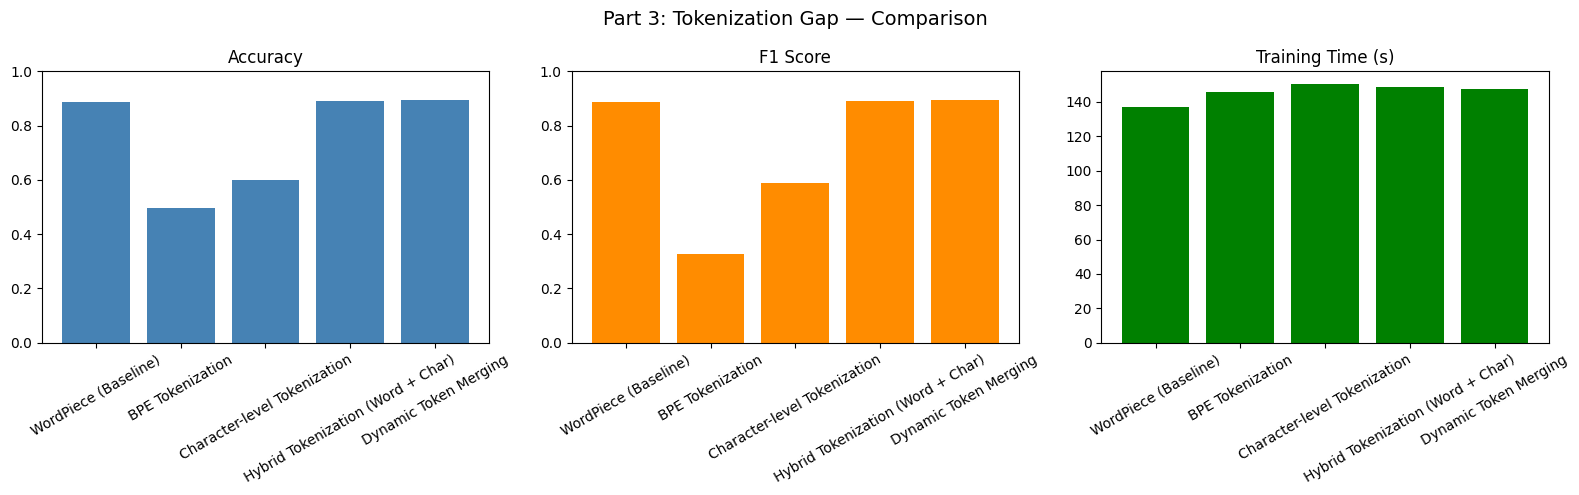

Plot saved.


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = results_df.index.tolist()

axes[0].bar(names, results_df['accuracy'], color='steelblue')
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(names, results_df['f1'], color='darkorange')
axes[1].set_title('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(names, results_df['training_time_s'], color='green')
axes[2].set_title('Training Time (s)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Part 3: Tokenization Gap — Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('tokenization_comparison.png', dpi=150)
plt.show()
print("Plot saved.")